In [1]:
import sys
sys.path.append('../src')
from preprocessing import load_and_optimize_data, create_features
from model import prepare_and_split, train_xgboost_baseline

# 1. Cargar datos optimizados
df = load_and_optimize_data('../data/raw/credit_card_transactions.csv')

# 2. Generar nuevas variables
df_features = create_features(df)

# 3. Dividir datos
X_train, X_test, y_train, y_test = prepare_and_split(df_features)

# 4. Entrenar y evaluar
model = train_xgboost_baseline(X_train, y_train, X_test, y_test)

Cargando datos desde: ../data/raw/credit_card_transactions.csv...
Uso de memoria inicial del DataFrame: 95.37 MB
Uso de memoria final tras optimización: 26.97 MB
Reducción de memoria: 71.7%
Iniciando Feature Engineering...
Feature Engineering completado. Nuevas variables añadidas.
Preparando datos para modelado...
Dimensiones Train: (400000, 24)
Dimensiones Test: (100000, 24)
Entrenando modelo XGBoost Baseline...

--- Resultados Baseline ---
PR-AUC Score: 0.0305

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     97664
           1       0.03      0.37      0.06      2336

    accuracy                           0.72    100000
   macro avg       0.51      0.55      0.45    100000
weighted avg       0.96      0.72      0.82    100000



# **Analisis Inicial**

## **1. El Impacto del scale_pos_weight**
Al usar este parámetro, le dijimos a XGBoost: "Equivocarte al clasificar un fraude cuesta 40 veces más que equivocarte con una transacción legítima".
El modelo hizo exactamente lo que le pedimos: se volvió extremadamente paranoico. Ante la menor duda, marca la transacción como fraude.

## **2. Lectura de Métricas**
* **Recall (Clase 1) = 0.37:** Estamos capturando el 37% de todos los fraudes reales. No está mal para un modelo sin optimizar.

* **Recall (Clase 0) = 0.73:** ¡Alerta roja! Esto significa que estamos aprobando solo el 73% de las transacciones legítimas. Es decir, estamos declinando por error el 27% de las compras de clientes honestos. En la vida real, esto colapsaría el centro de atención al cliente de cualquier banco.

* **Precision (Clase 1) = 0.03:** De cada 100 transacciones que nuestro modelo bloquea por sospecha de fraude, solo 3 son realmente fraude. Los otros 97 son Falsos Positivos.

* **PR-AUC = 0.0305:** Esta es nuestra línea base. El objetivo del proyecto será subir este número calibrando el modelo.

## **3. Optimizacion y Ajustes**

El problema radica en que classification_report utiliza un umbral de decisión (threshold) por defecto del 50% (0.5). Es decir, si el modelo dice que hay un 51% de probabilidad de fraude, lo bloquea.

Como forzamos al modelo a ser paranoico con el scale_pos_weight, muchas transacciones legítimas están arrojando, digamos, un 60% de probabilidad de fraude en la cabeza del algoritmo.

Tenemos dos caminos claros para mejorar drásticamente estas métricas y acercarnos a un modelo listo para producción:

* Optimización de Umbral (Threshold Moving): Escribir un pequeño bloque de código para encontrar el punto de corte óptimo (bloquear solo si la probabilidad es > 0.85) para equilibrar la precisión y el recall sin reentrenar el modelo.

* Ajuste de Hiperparámetros (Tuning): El modelo actual es muy básico (max_depth=5, n_estimators=100). Podemos usar validación cruzada para encontrar hiperparámetros que permitan al árbol crear reglas mucho más complejas y precisas.

# **Optimización de Umbral (Threshold Moving)**

Umbral Óptimo Encontrado: 0.5687


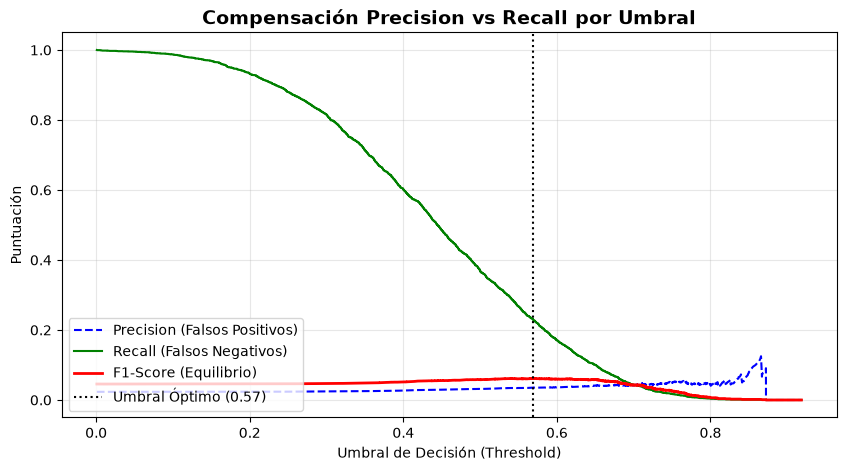


--- Classification Report con Umbral Óptimo ---
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     97664
           1       0.04      0.23      0.06      2336

    accuracy                           0.83    100000
   macro avg       0.51      0.54      0.49    100000
weighted avg       0.96      0.83      0.89    100000



In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

# 1. Extraemos las probabilidades de la clase positiva (Fraude)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Calculamos Precision y Recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 3. Calculamos el F1-Score matemático para cada umbral (evitando divisiones por cero)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-5)

# 4. Encontramos el índice del mejor F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Umbral Óptimo Encontrado: {optimal_threshold:.4f}")

# 5. Visualización para tu portafolio
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Falsos Positivos)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Falsos Negativos)')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, label='F1-Score (Equilibrio)')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Umbral Óptimo ({optimal_threshold:.2f})')

plt.title('Compensación Precision vs Recall por Umbral', fontsize=14, fontweight='bold')
plt.xlabel('Umbral de Decisión (Threshold)')
plt.ylabel('Puntuación')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Evaluamos el modelo con el nuevo umbral
print("\n--- Classification Report con Umbral Óptimo ---")
# Si la probabilidad es mayor al umbral, es fraude (1), si no, es legítimo (0)
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal))

## **1. El lado positivo (Experiencia del Cliente)**

Al mover el umbral a 0.5687, el Recall de la clase 0 (transacciones legítimas) subió de 0.73 a 0.85.

En el mundo real, esto significa que dejamos de bloquear el 12% de las tarjetas de clientes honestos.

## **2. La cruda realidad (Riesgo y Pérdidas)**

* Recall de Fraude (0.23): Ahora solo estamos capturando el 23% de los fraudes. El 77% de los estafadores se están saliendo con la suya.

* Precisión de Fraude (0.04): Por cada 100 alertas de fraude que emite nuestro sistema, 96 siguen siendo falsas alarmas.

* Análisis Visual: La línea azul punteada (Precisión). Es plana y cercana a cero casi todo el trayecto, levantándose erráticamente solo al final. La línea roja (F1-Score) apenas se despega del suelo. Esto nos grita que el modelo no está encontrando la frontera de decisión.

## **3. El Diagnóstico Técnico**

El problema ya no es el umbral. El problema es que nuestro modelo Baseline (con una profundidad máxima de max_depth=5 y solo 100 árboles) es demasiado simple para la complejidad matemática de los datos. Al tener variables que no son linealmente correlacionadas, XGBoost necesita árboles mucho más profundos para crear las reglas compuestas necesarias para aislar a los estafadores.